First, format and extract the part of the root file we need. Check against the histogram from the CERN root viewer to confirm.

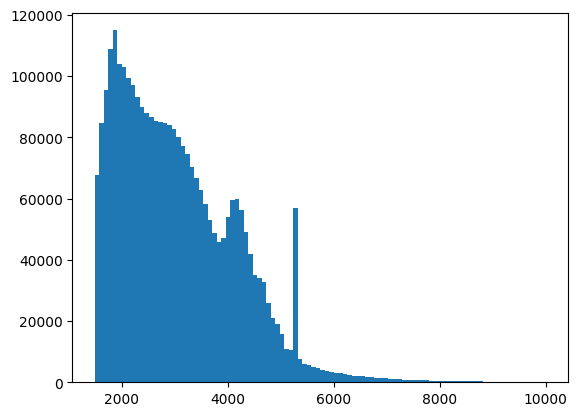

In [2]:
import uproot
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

file = uproot.open('data/00385270_00000001_1.dvntuple.root')
mm_tree = file["MyDecayTree_muons/DecayTree;1"]["B0_MM"]
data_array = mm_tree.array(library="np")

plt.hist(data_array, bins=100)
plt.show()









That seems to work. Now to filter specifically for strange B mesons ($B_s$), which have a mass of 5366.3 $MeV/c^2$. We're just doing this by limiting the histogram's range to +-200 of the expected energy.

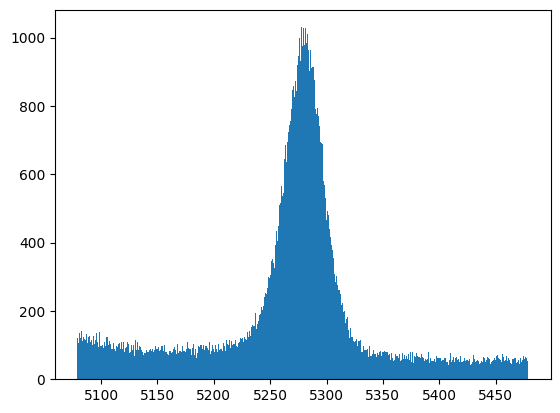

In [3]:
plt.hist(data_array, range=(5079,5479),bins=500)
plt.show()

# Data selection: 

['MyDecayTree_muons;1', 'MyDecayTree_muons/DecayTree;1', 'GetIntegratedLuminosity;1', 'GetIntegratedLuminosity/LumiTuple;1']
['B0_MCORR', 'B0_MCORRERR', 'B0_MCORRVERTEXERR', 'B0_PTREL', 'B0_ENDVERTEX_X', 'B0_ENDVERTEX_Y', 'B0_ENDVERTEX_Z', 'B0_ENDVERTEX_XERR', 'B0_ENDVERTEX_YERR', 'B0_ENDVERTEX_ZERR', 'B0_ENDVERTEX_CHI2', 'B0_ENDVERTEX_NDOF', 'B0_ENDVERTEX_COV_', 'B0_OWNPV_X', 'B0_OWNPV_Y', 'B0_OWNPV_Z', 'B0_OWNPV_XERR', 'B0_OWNPV_YERR', 'B0_OWNPV_ZERR', 'B0_OWNPV_CHI2', 'B0_OWNPV_NDOF', 'B0_OWNPV_COV_', 'B0_IP_OWNPV', 'B0_IPCHI2_OWNPV', 'B0_FD_OWNPV', 'B0_FDCHI2_OWNPV', 'B0_DIRA_OWNPV', 'B0_P', 'B0_PT', 'B0_PE', 'B0_PX', 'B0_PY', 'B0_PZ', 'B0_MM', 'B0_MMERR', 'B0_M', 'B0_ID', 'B0_TAU', 'B0_TAUERR', 'B0_TAUCHI2', 'B0_L0Global_Dec', 'B0_L0Global_TIS', 'B0_L0Global_TOS', 'B0_Hlt1Global_Dec', 'B0_Hlt1Global_TIS', 'B0_Hlt1Global_TOS', 'B0_Hlt1Phys_Dec', 'B0_Hlt1Phys_TIS', 'B0_Hlt1Phys_TOS', 'B0_Hlt2Global_Dec', 'B0_Hlt2Global_TIS', 'B0_Hlt2Global_TOS', 'B0_Hlt2Phys_Dec', 'B0_Hlt2Phys_TIS',

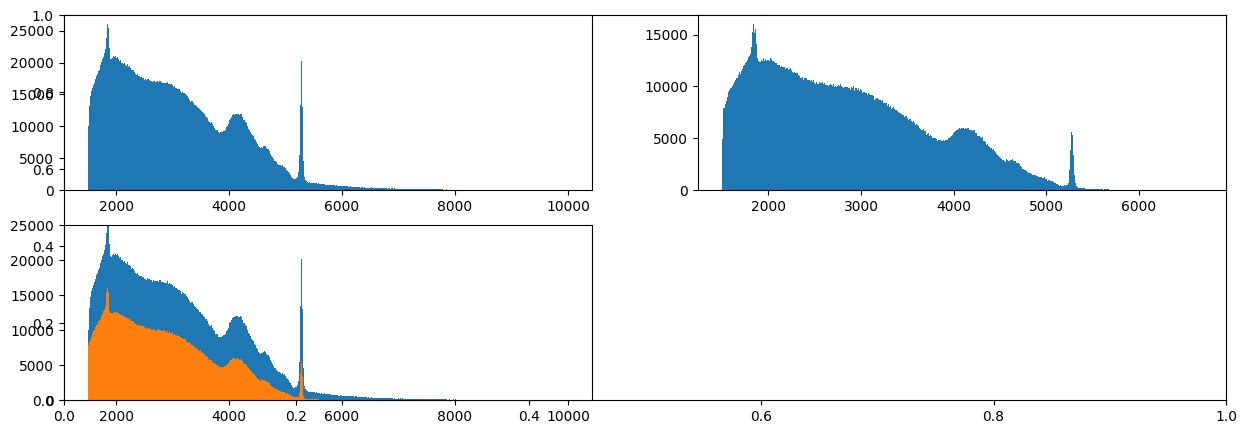

In [53]:
import uproot
import matplotlib.pyplot as plt
import pandas as pd

file = uproot.open('data/00385270_00000001_1.dvntuple.root')

events = file[file.keys()[1]]
keys = events.keys()

print(file.keys())
print(events.keys())

# list of variables to add to the dataframe. variable at index 0 will be the variable which is getting cut by the rest
variables = []

# Our base variable
variables.append("B0_MM")
arr_before = events[variables[0]].array(library="pd")

# Basic test appending momentum X and Y to the variable list
variables.extend([
    "B0_PX",
    "B0_PY",
    "B0_M",
    "B0_MMERR"
])

var_dataframe = events.arrays(variables, library="pd")
#print(var_dataframe)

# Drops all rows where the X and Y momenta don't fall between min and max
min = -15000
max = 15000

var_dataframe = var_dataframe.query(f"{min} < B0_PX < {max}")
var_dataframe = var_dataframe.query(f"{min} < B0_PX < {max}")

# Drops all rows where the detected particle's mass doesn't fall between min and max
min = 0
max = 50000

var_dataframe = var_dataframe.query(f"{min} < B0_M < {max}")

# Drops all rows where MM error is greater than a certain amount
min = 0
max = 15

var_dataframe = var_dataframe.query(f"{min} < B0_MMERR < {max}")

arr_after = var_dataframe["B0_MM"]

plt.subplots(figsize=(15, 5))
plt.subplot(2,2,1)
plt_before = plt.hist(arr_before, bins=500)



plt.subplot(2,2,2)
plt_after = plt.hist(arr_after, bins=500)


plt.subplot(2,2,3)
plt_before = plt.hist(arr_before, bins=500)
plt_after = plt.hist(arr_after, bins=500)

plt.ylim(0,25000)


plt.show()